# Task 1: Exploring and Visualizing the Iris Dataset
### DevelopersHub Corporation — Data Science and Analytics Internship

---

## Problem Statement

The goal of this task is to explore and visualize the famous **Iris dataset** to understand its structure, distributions, and relationships between features.

We will practise core data science skills including:
- Loading and inspecting a dataset using **pandas**
- Summarizing data with statistics
- Creating meaningful visualizations using **matplotlib** and **seaborn**

## Dataset Description

The Iris dataset contains **150 samples** of iris flowers from 3 species:

| Feature | Description |
|---|---|
| sepal_length | Length of the sepal (cm) |
| sepal_width | Width of the sepal (cm) |
| petal_length | Length of the petal (cm) |
| petal_width | Width of the petal (cm) |
| species | **Target** — setosa / versicolor / virginica |


## Step 1: Import Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# The Iris dataset directly from seaborn
df = sns.load_dataset("iris")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(10)

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 3: Dataset Understanding and Inspection

In [7]:
# --- Dataset Structure ---
print("=== SHAPE ===")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("=== DATA TYPES ===")
print(df.dtypes)

print("=== FIRST 5 ROWS ===")
df.head()

=== SHAPE ===
Rows: 150  |  Columns: 5
=== COLUMN NAMES ===
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
=== DATA TYPES ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
=== FIRST 5 ROWS ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
# Statistical summary of all numerical features
print("=== STATISTICAL SUMMARY ===")
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [9]:
# missing values
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# species distribution
print("=== SPECIES COUNT ===")
print(df["species"].value_counts())

=== MISSING VALUES ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
=== SPECIES COUNT ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Step 4: Data Cleaning

We check for duplicates and missing values before visualization.

In [10]:
#  duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate row(s). New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean!")

print(f"Missing values: {df.isnull().sum().sum()}")
print("Dataset is ready for analysis!")

Duplicate rows: 1
Removed 1 duplicate row(s). New shape: (149, 5)
Missing values: 0
Dataset is ready for analysis!


## Step 5: Exploratory Data Analysis (EDA) — Visualizations

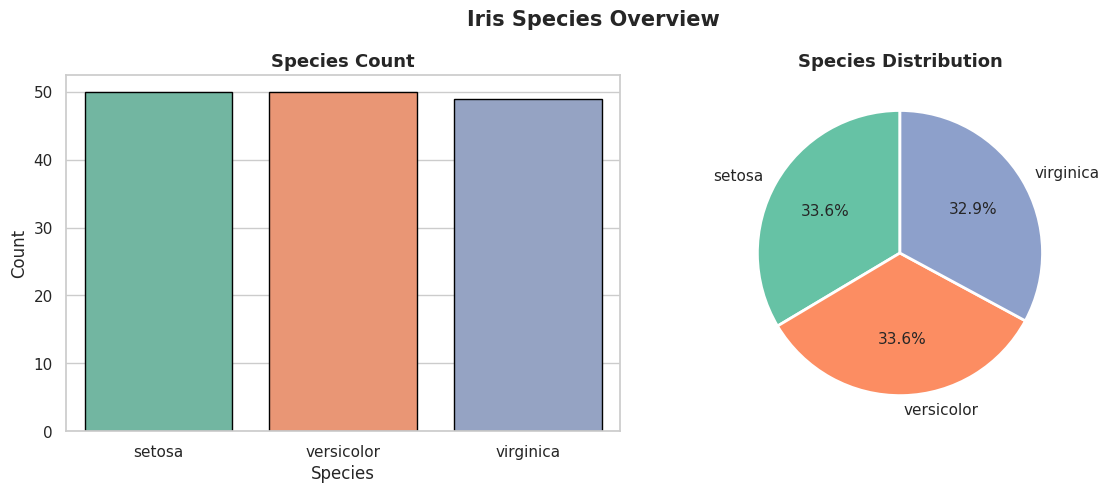

In [18]:
# --- Plot 1: Species Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x="species", data=df, palette="Set2", ax=axes[0], edgecolor="black")
axes[0].set_title("Species Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Count")

# Pie chart
species_counts = df["species"].value_counts()
axes[1].pie(species_counts, labels=species_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", 3),
            wedgeprops={"edgecolor": "white", "linewidth": 2}, startangle=90)
axes[1].set_title("Species Distribution", fontsize=13, fontweight="bold")

plt.suptitle("Iris Species Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


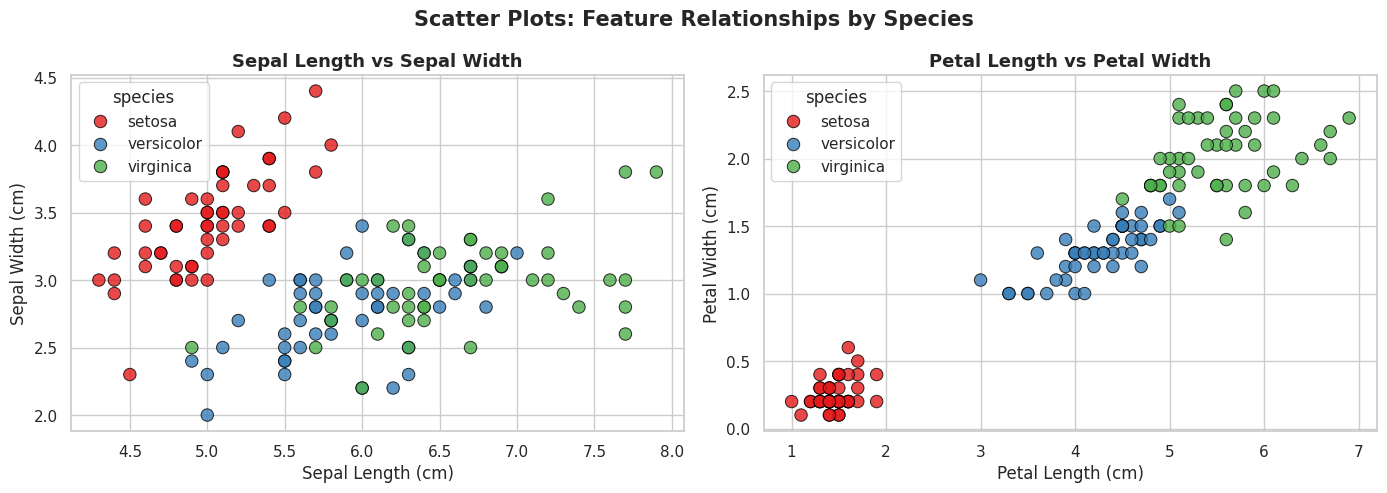

In [19]:
# --- Plot 2: Scatter Plots — Relationships Between Variables ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sepal: Length vs Width
sns.scatterplot(data=df, x="sepal_length", y="sepal_width",
                hue="species", palette="Set1", s=80,
                alpha=0.8, edgecolor="black", ax=axes[0])
axes[0].set_title("Sepal Length vs Sepal Width", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")

# Petal: Length vs Width
sns.scatterplot(data=df, x="petal_length", y="petal_width",
                hue="species", palette="Set1", s=80,
                alpha=0.8, edgecolor="black", ax=axes[1])
axes[1].set_title("Petal Length vs Petal Width", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.suptitle("Scatter Plots: Feature Relationships by Species", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


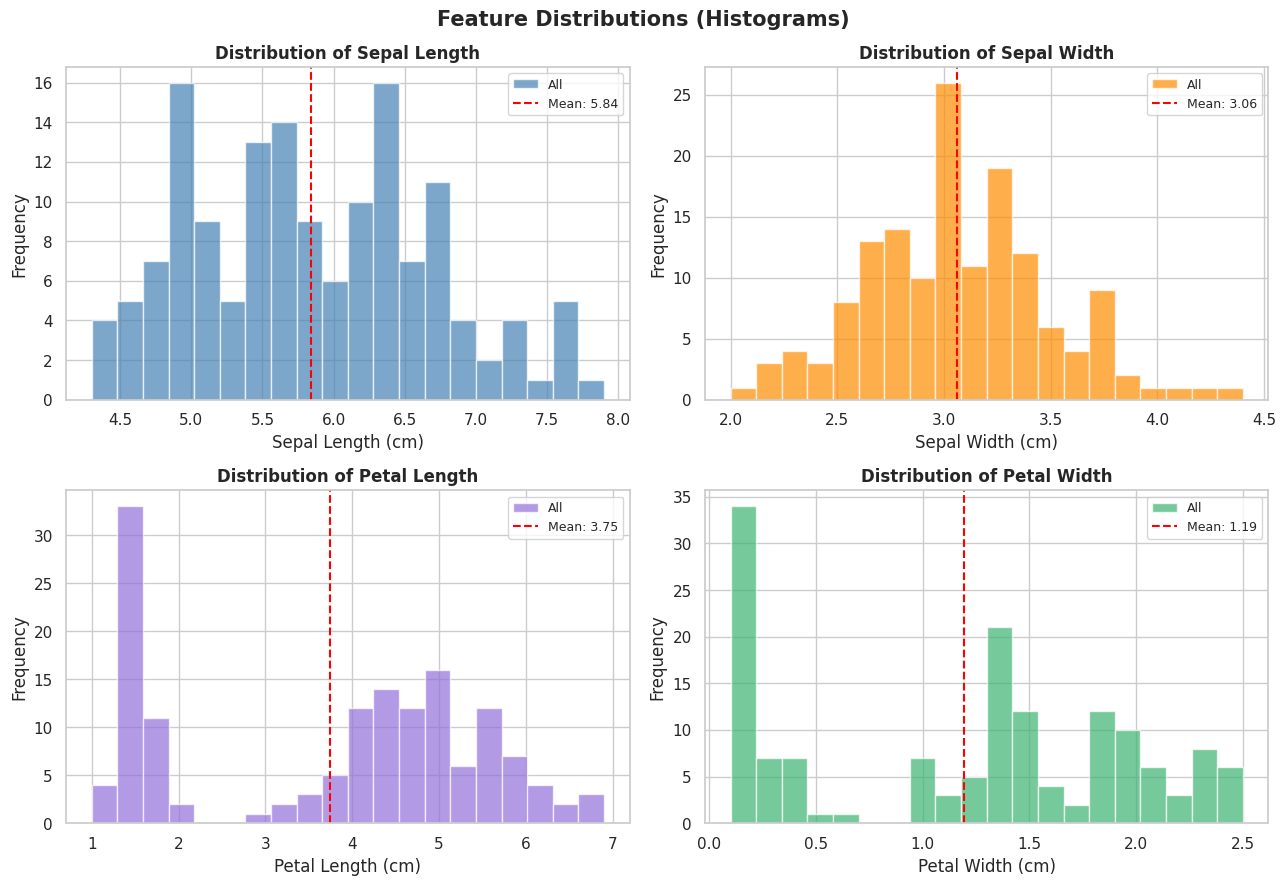

In [21]:
# --- Plot 3: Histograms — Feature Distributions ---
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
colors = ["steelblue", "darkorange", "mediumpurple", "mediumseagreen"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, color) in enumerate(zip(features, colors)):
    # Overall histogram
    axes[i].hist(df[feat], bins=20, color=color, edgecolor="white", alpha=0.7, label="All")
    axes[i].set_title(f"Distribution of {feat.replace("_", " ").title()}",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel(feat.replace("_", " ").title() + " (cm)")
    axes[i].set_ylabel("Frequency")
    # Add mean line
    mean_val = df[feat].mean()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
                    label=f"Mean: {mean_val:.2f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Feature Distributions (Histograms)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


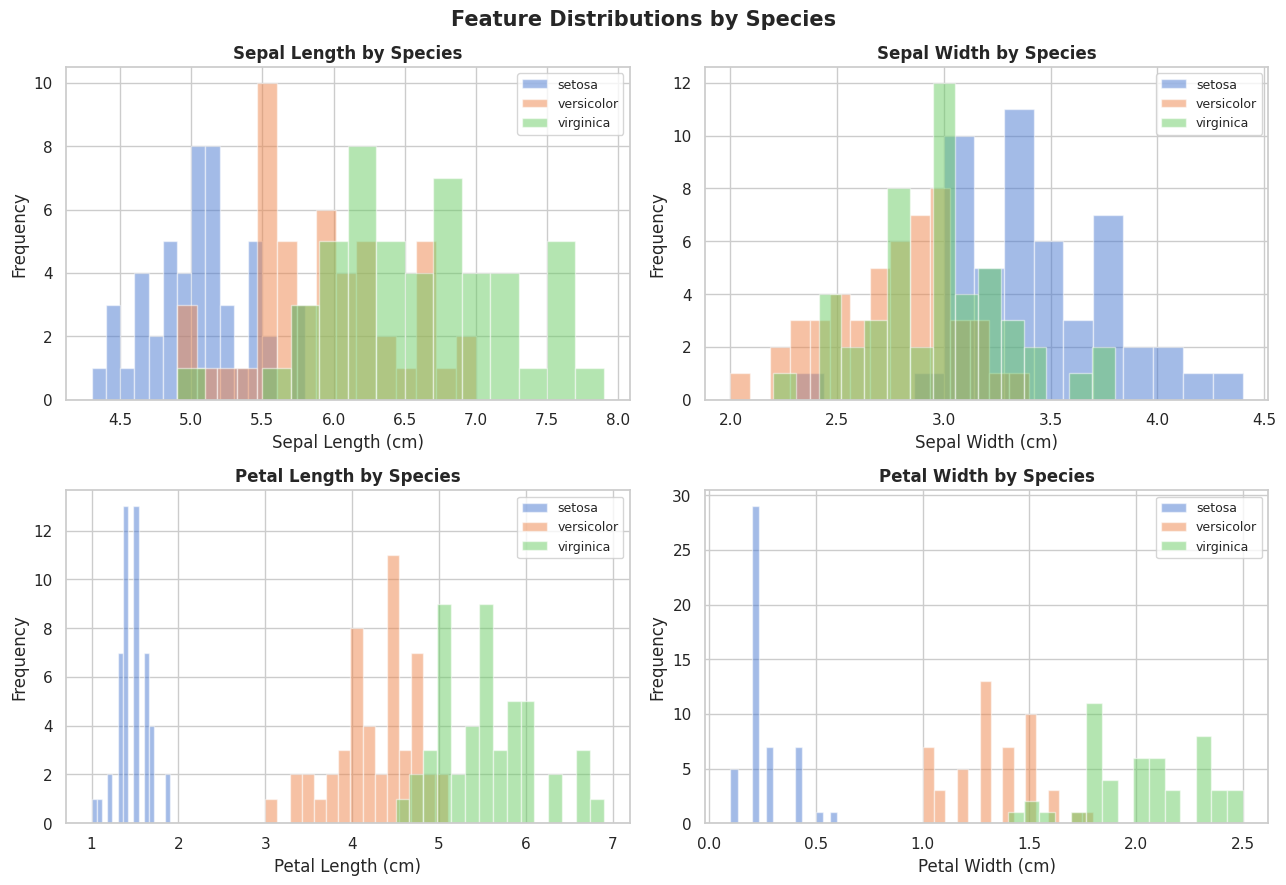

In [22]:
# --- Plot 4: Histogram by Species (KDE overlay) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species in df["species"].unique():
        subset = df[df["species"] == species][feat]
        axes[i].hist(subset, bins=15, alpha=0.5, label=species, edgecolor="white")
    axes[i].set_title(f"{feat.replace(chr(95), chr(32)).title()} by Species",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel(feat.replace("_", " ").title() + " (cm)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

plt.suptitle("Feature Distributions by Species", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

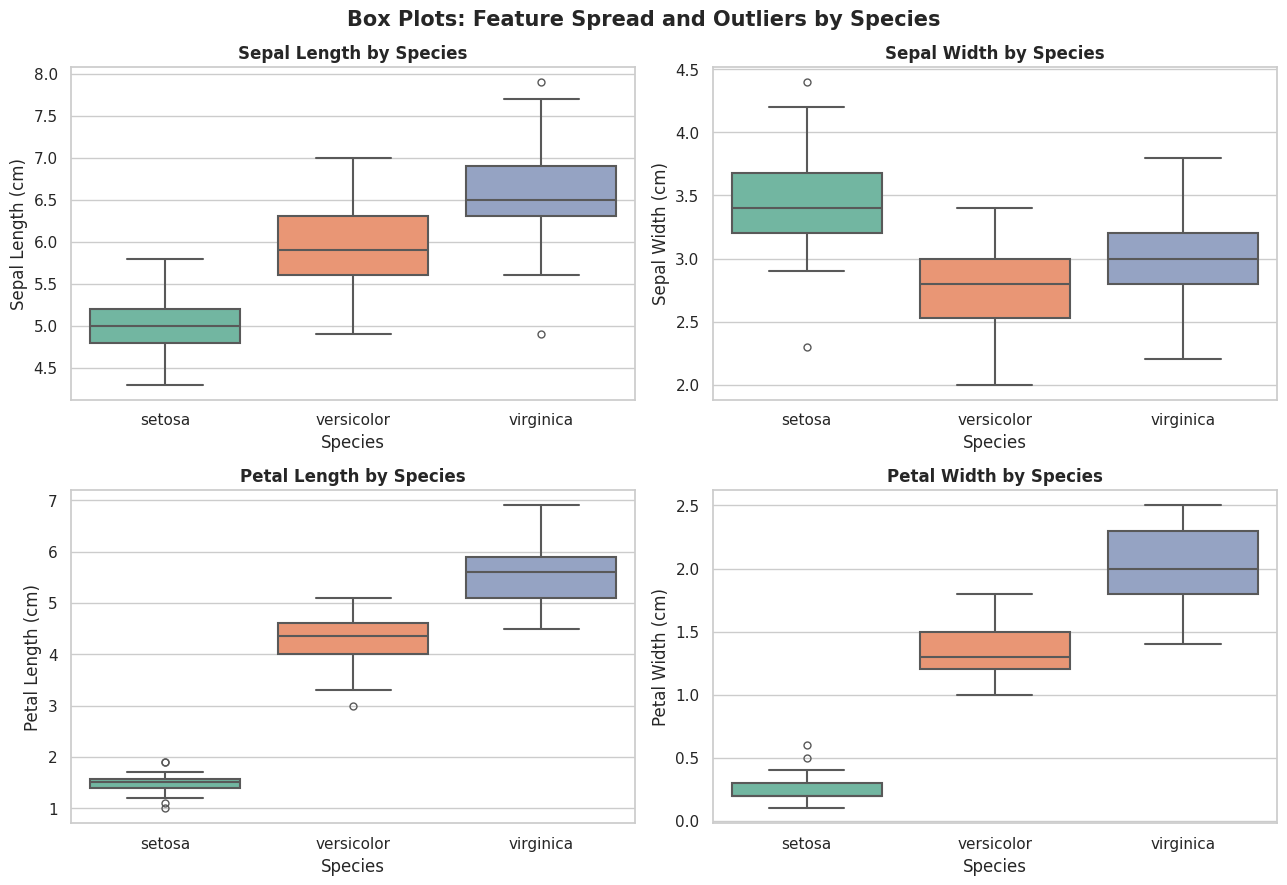

In [23]:
# --- Plot 5: Box Plots — Spread and Outliers ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x="species", y=feat, data=df,
                palette="Set2", ax=axes[i],
                linewidth=1.5, flierprops=dict(marker="o", color="red", markersize=5))
    axes[i].set_title(f"{feat.replace("_", " ").title()} by Species",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(feat.replace("_", " ").title() + " (cm)")

plt.suptitle("Box Plots: Feature Spread and Outliers by Species", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


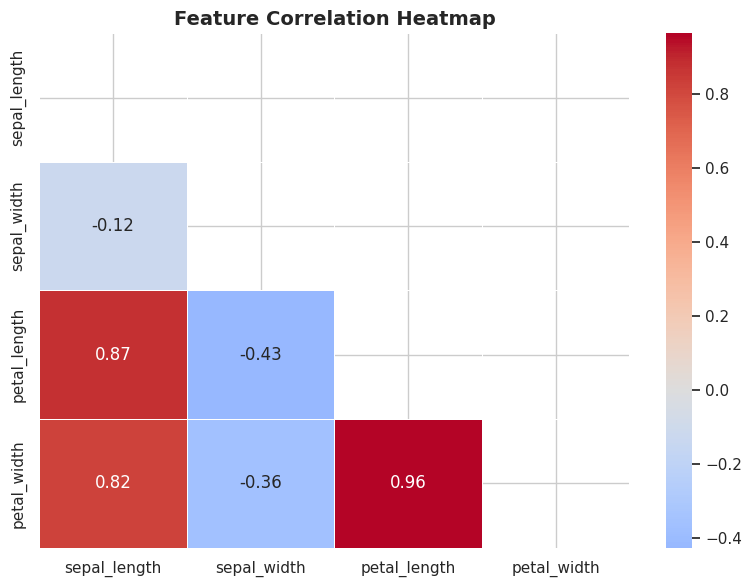

In [24]:
# --- Plot 6: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, mask=mask,
            annot_kws={"size": 12})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


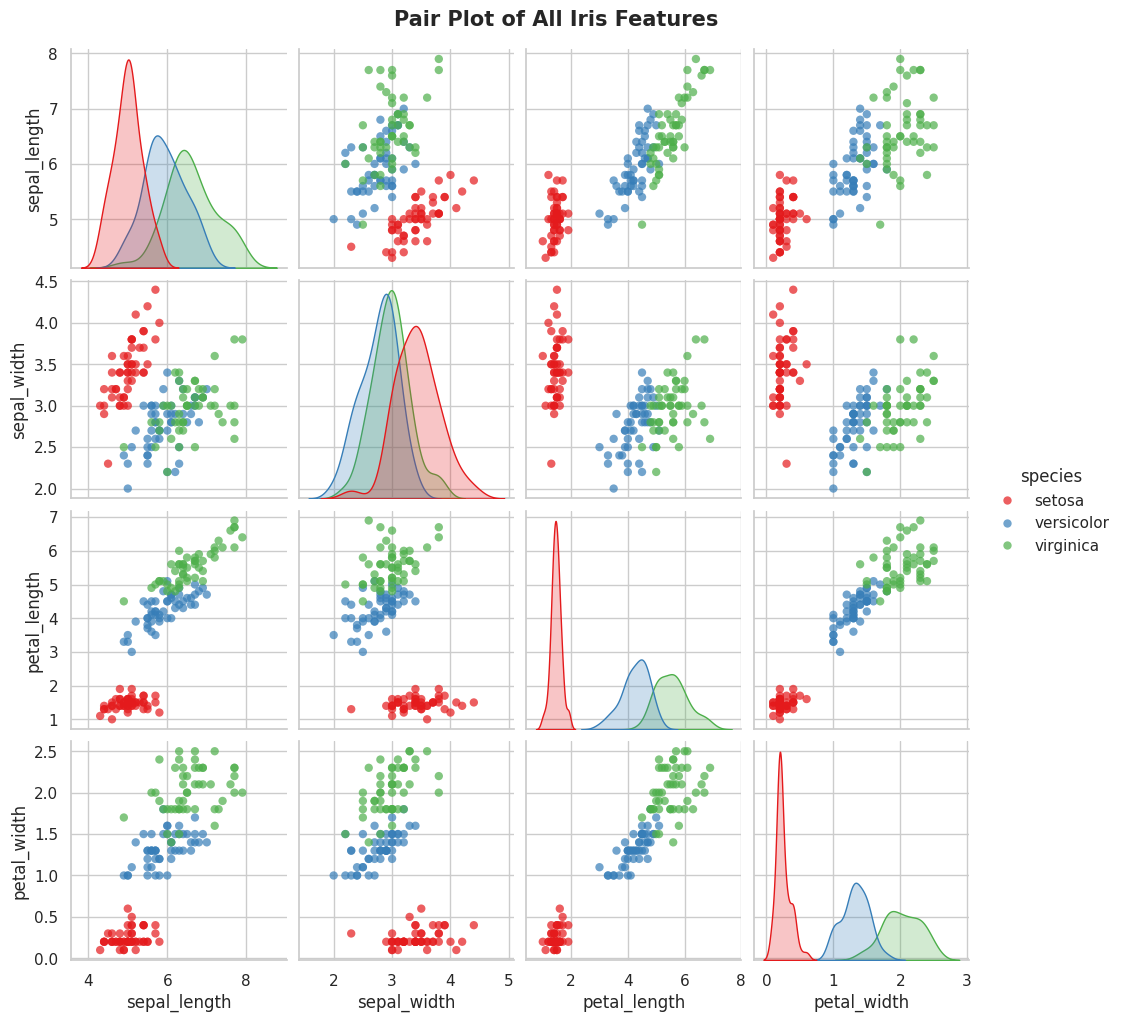

In [25]:
# --- Plot 7: Pair Plot — All Feature Combinations ---
pair_plot = sns.pairplot(df, hue="species", palette="Set1",
                         plot_kws={"alpha": 0.7, "edgecolor": "none"},
                         diag_kind="kde")
pair_plot.fig.suptitle("Pair Plot of All Iris Features",
                        fontsize=15, fontweight="bold", y=1.02)
plt.show()

## Step 6: Conclusion

### Summary of Findings

| Feature | Mean | Std Dev | Key Observation |
|---|---|---|---|
| sepal_length | 5.84 cm | 0.83 | Moderate variation across species |
| sepal_width | 3.06 cm | 0.44 | Least variation overall |
| petal_length | 3.76 cm | 1.77 | Huge difference across species |
| petal_width | 1.20 cm | 0.76 | Best single separator |

### Key Insights

1. **Setosa** is the easiest to identify — its petals are much smaller than the other two species.
2. **Petal dimensions** (length and width) are far better at separating species than sepal dimensions.
3. **Petal length and petal width** are highly correlated (r = 0.96), meaning they carry similar information.
4. **Versicolor and Virginica** overlap slightly in all features, making them harder to distinguish.
5. The dataset is **perfectly balanced** with 50 samples per species — no class imbalance issues.

### Skills Demonstrated
- Data loading and inspection with **pandas** (.shape, .columns, .head(), .describe())
- Data cleaning (duplicate and null value checks)
- Visualization using **matplotlib** and **seaborn**: scatter plots, histograms, box plots, heatmap, pair plot

---
